# From Walking to Football: Gait Analysis

## Introduction
In this notebook we will explore the differences between walking barefoot and walking in football boots. The goal is to find and analyze the differences in the dynamics of the walking pattern. 

Inertial data collected with an accelerometer and a gyroscope will be used. The collected data will be noisy, so a filtering phase will be necessary. 

The data were collected from 10 subjects with very different heights and body weights. The recordings were made in two separate sessions. Both groups walked in a straight line on a flat, rigid surface.

Features will be extracted from each signal and then plotted. In such a plot, subjects with similar physical characteristics should tend to group together in different regions of the Cartesian plane. In addition, a slight separation should be visible between the measurements taken barefoot and those taken with shoes.

### Author
Marco Mammoliti     
Email: S5564736@studenti.unige.it, mammolo103@gmail.com

![Alt des: This image shows the direction of the axes](../dati/im.png)

## Methods

During the filtering and analysis phase, the signal will be processed using several functions.

```pd.read_csv```  
A method for reading data from CSV files. It returns a data structure with a label for each column in the CSV file.

```gaussian_filter() ```   
Applies a Gaussian filter by convolution. It returns an array with exactly the same shape as the input, but with filtered values.

```np.fft.fft()```     
A function that computes the discrete Fourier transform of the input signal. It returns the frequency spectrum of the signal.

```np.fft.fftfreq()```     
This function computes the sample frequencies of the discrete Fourier transform. The return value is an array containing all the frequencies that can appear in the signal.


## Experiment
As stated at the beginning, measurements were taken on 10 different subjects, for a total of 20 recordings.
The experiments were carried out on two different days. All the subjects walked in a straight line on a tiled floor.

### Hypothesis:   
Since football boots have studs, significant differences in the data are expected. The studs, besides being rigid, are located on the outermost part of the sole and are not evenly distributed.       
The differences are expected mainly along the vertical axis (y) and the horizontal axis (x) for the accelerometer, and along the horizontal axis (z) for the gyroscope, which measures external/internal rotations.  
Indeed, walking in football boots is an abrupt, robotic and unnatural movement, so clear differences are expected.

## Uploading the data
Below, the __data__ collected during the experiments will be imported.      
They will be organized into __two 2 x 10 matrices__. The two matrices will contain, __respectively__, the __accelerometer__ and __gyroscope__ data. Each matrix has two rows, which allows the data collected __barefoot__ (under __index 0__) and __with football boots__ (under __index 1__) to be kept separate.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt


nomi = "stelli", "deprati", "fazio", "foreman", "macchiavello", "massoni", "medica", "paladini", "tassara", "zanone"
# here the data structure is created
# it will consist of two 2x10 matrices
size, size2 = 2, 10

Accelerometro = [[0 for _ in range(size2)] for _ in range(size)]
Giroscopio = [[0 for _ in range(size2)] for _ in range(size)]

for i in range(size2):
    string = '../dati/scalzi/'+ nomi[i] + '/AccelerometerUncalibrated.csv'
    Accelerometro[0][i] = pd.read_csv(string)
    string = '../dati/scalzi/'+ nomi[i] + '/GyroscopeUncalibrated.csv'
    Giroscopio[0][i] = pd.read_csv(string)

    string = '../dati/scarpe/'+ nomi[i] + '/AccelerometerUncalibrated.csv'
    Accelerometro[1][i] = pd.read_csv(string)
    string = '../dati/scarpe/'+ nomi[i] + '/GyroscopeUncalibrated.csv'
    Giroscopio[1][i] = pd.read_csv(string)
    



Below, the data will be trimmed. This keeps only the meaningful part of the collected data.

In [26]:
### Data trimming
##### trimming of barefoot data         ##### with shoes

# stelli from 730 to 1500                   ---- from 500 to 1500
# deprati from 1000 to 1500                 ---- from 750 to 1300
# fazio from 680 to 2080                    ---- from 500 to 1850
# foreman from 1200 to 2400                 ---- from 480 to 1850
# macchiavello from 500 to 1000             ---- from 550 to 1050
# massoni from 750 to 2250                  ---- from 980 to 2400
# medica from 1200 to 2400                  ---- from 1000 to 2100
# paladini from 1200 to 2400                ---- from 550 to 1700
# tassara from 1550 to 2400                  ---- from 980 to 2250
# zanone from 980 to 2200                   ---- from 1180 to 2400

Accelerometro[0][0] = Accelerometro[0][0][730:1500]
Accelerometro[0][1] = Accelerometro[0][1][1000:1500]
Accelerometro[0][2] = Accelerometro[0][2][680:2080]
Accelerometro[0][3] = Accelerometro[0][3][1200:2400]
Accelerometro[0][4] = Accelerometro[0][4][500:1000]
Accelerometro[0][5] = Accelerometro[0][5][750:2250]
Accelerometro[0][6] = Accelerometro[0][6][1200:2400]
Accelerometro[0][7] = Accelerometro[0][7][1200:2400]
Accelerometro[0][8] = Accelerometro[0][8][1550:2400]
Accelerometro[0][9] = Accelerometro[0][9][980:2200]

Accelerometro[1][0] = Accelerometro[1][0][500:1500]
Accelerometro[1][1] = Accelerometro[1][1][750:1300]
Accelerometro[1][2] = Accelerometro[1][2][500:1850]
Accelerometro[1][3] = Accelerometro[1][3][480:1850]
Accelerometro[1][4] = Accelerometro[1][4][550:1050]
Accelerometro[1][5] = Accelerometro[1][5][980:2400]
Accelerometro[1][6] = Accelerometro[1][6][1000:2100]
Accelerometro[1][7] = Accelerometro[1][7][550:1700]
Accelerometro[1][8] = Accelerometro[1][8][980:2250]
Accelerometro[1][9] = Accelerometro[1][9][1180:2400]

Giroscopio[0][0] = Giroscopio[0][0][730:1500]
Giroscopio[0][1] = Giroscopio[0][1][1000:1500]
Giroscopio[0][2] = Giroscopio[0][2][680:2080]
Giroscopio[0][3] = Giroscopio[0][3][1200:2400]
Giroscopio[0][4] = Giroscopio[0][4][500:1000]
Giroscopio[0][5] = Giroscopio[0][5][750:2250]
Giroscopio[0][6] = Giroscopio[0][6][1200:2400]
Giroscopio[0][7] = Giroscopio[0][7][1200:2400]
Giroscopio[0][8] = Giroscopio[0][8][1550:2400]
Giroscopio[0][9] = Giroscopio[0][9][980:2200]

Giroscopio[1][0] = Giroscopio[1][0][500:1500]
Giroscopio[1][1] = Giroscopio[1][1][750:1300]
Giroscopio[1][2] = Giroscopio[1][2][500:1850]
Giroscopio[1][3] = Giroscopio[1][3][480:1850]
Giroscopio[1][4] = Giroscopio[1][4][550:1050]
Giroscopio[1][5] = Giroscopio[1][5][980:2400]
Giroscopio[1][6] = Giroscopio[1][6][1000:2100]
Giroscopio[1][7] = Giroscopio[1][7][550:1700]
Giroscopio[1][8] = Giroscopio[1][8][980:2250]
Giroscopio[1][9] = Giroscopio[1][9][1180:2400]

## A first look at the data
### First plot (raw data)

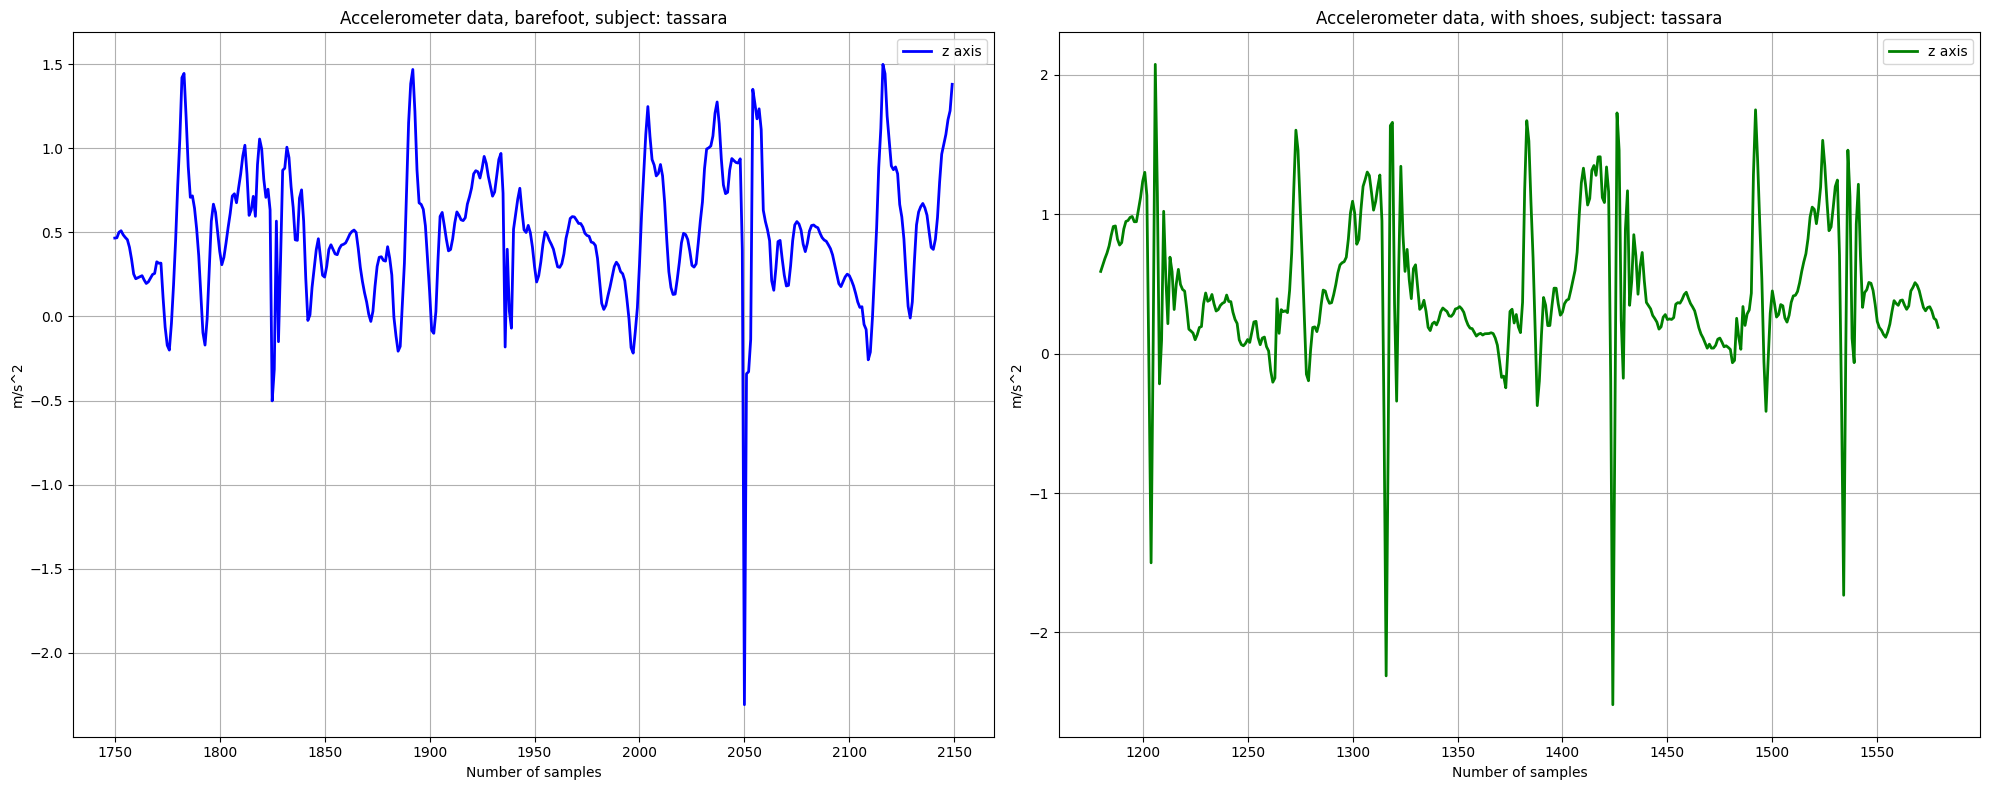

In [27]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(Accelerometro[0][8]["z"][200:600], 'b', label="z axis",linewidth=2)
plt.title("Accelerometer data, barefoot, subject: " + nomi[8])
plt.xlabel("Number of samples")
plt.ylabel("m/s^2")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Accelerometro[1][8]["z"][200:600], 'g', label="z axis",linewidth=2)
plt.title("Accelerometer data, with shoes, subject: " + nomi[8])
plt.xlabel("Number of samples")
plt.ylabel("m/s^2")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()


In this first exploration of the data, the accelerometer's "z" axis was examined. Depending on how the device is positioned, the values can have different meanings: at the time of measurement, a positive value indicates forward acceleration, while a negative value represents backward acceleration.

#### What do we notice?
1. It is immediately clear that the walking appears stiffer. It is also evident that the negative acceleration has much stronger peaks.
2. In addition, a repeating pattern is seen more clearly when football boots are used.

### Second plot (raw data)

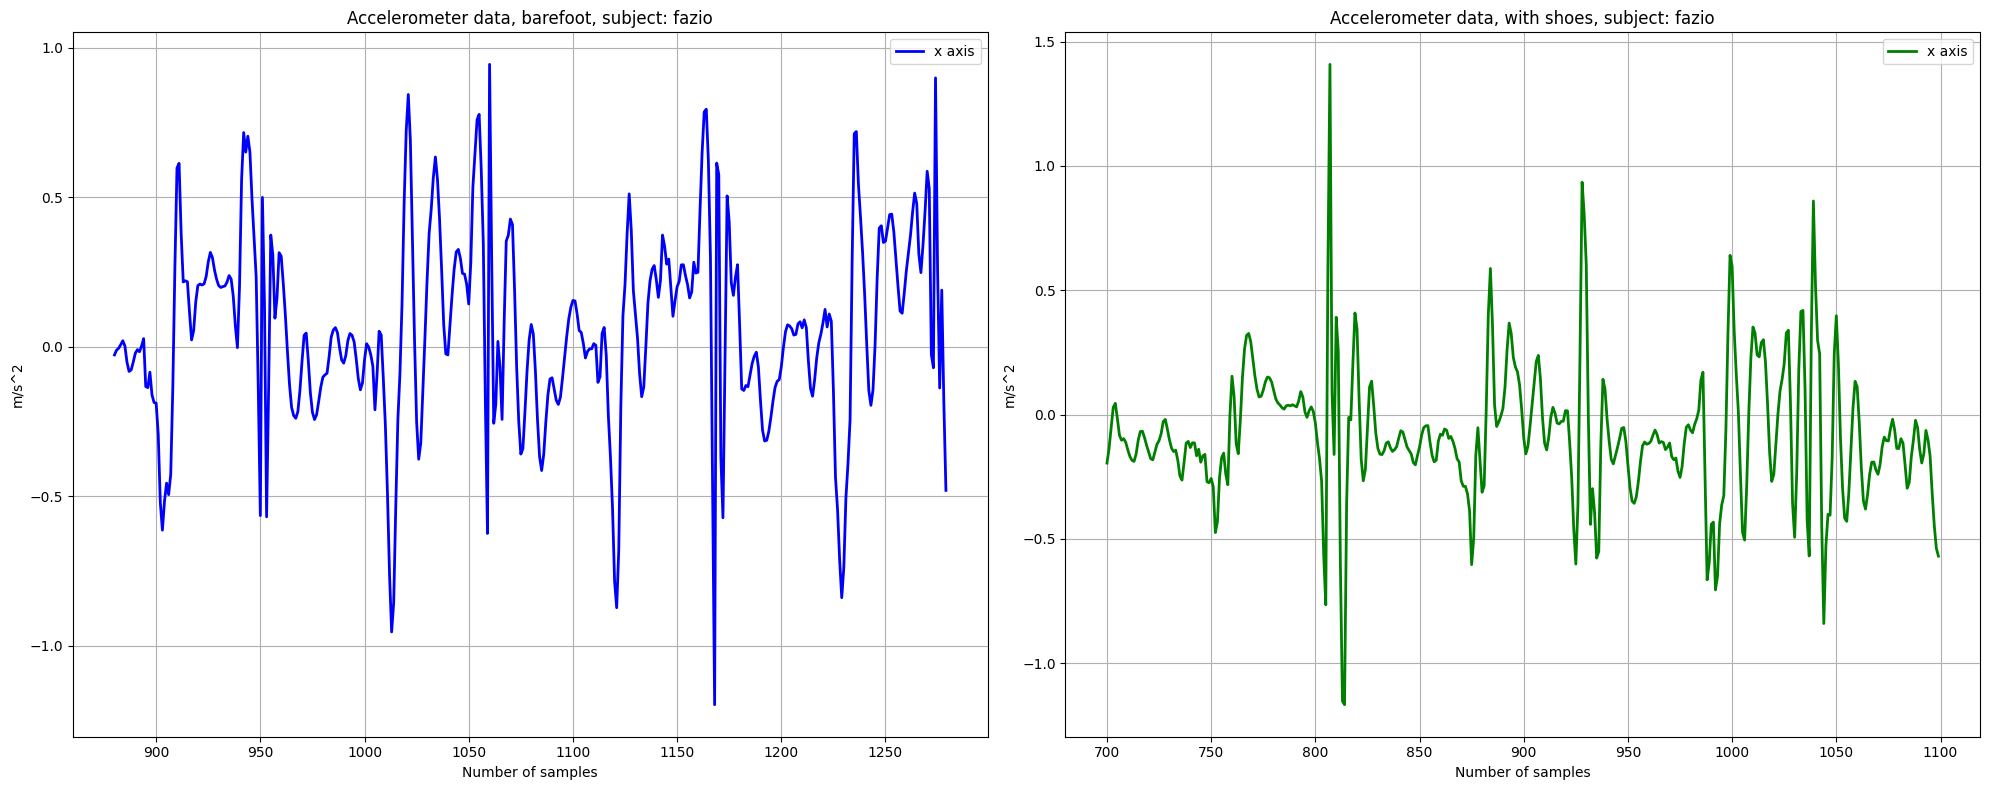

In [28]:
plt.figure(figsize=(20,8))
plt.subplot(1, 2, 1)
plt.plot(Accelerometro[0][2]["x"][200:600], 'b', label="x axis",linewidth=2)
plt.title("Accelerometer data, barefoot, subject: " + nomi[2])
plt.xlabel("Number of samples")
plt.ylabel("m/s^2")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Accelerometro[1][2]["x"][200:600], 'g', label="x axis",linewidth=2)
plt.title("Accelerometer data, with shoes, subject: " + nomi[2])
plt.xlabel("Number of samples")
plt.ylabel("m/s^2")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In this visualization we look at the accelerometer's "x" axis. A positive reading from the instrument indicates acceleration toward the inside of the foot, whereas a negative one indicates acceleration toward the outside.

#### What do we notice?
1. The signal collected with shoes is, on average, negative, whereas the one collected barefoot is positive. 
2. Moreover, positive peaks greater than 0.5 m/s^2 (acceleration toward the inside) are more frequent when walking barefoot.
3. The peaks recorded with shoes are steeper than those recorded without shoes.

### Third plot (raw data)

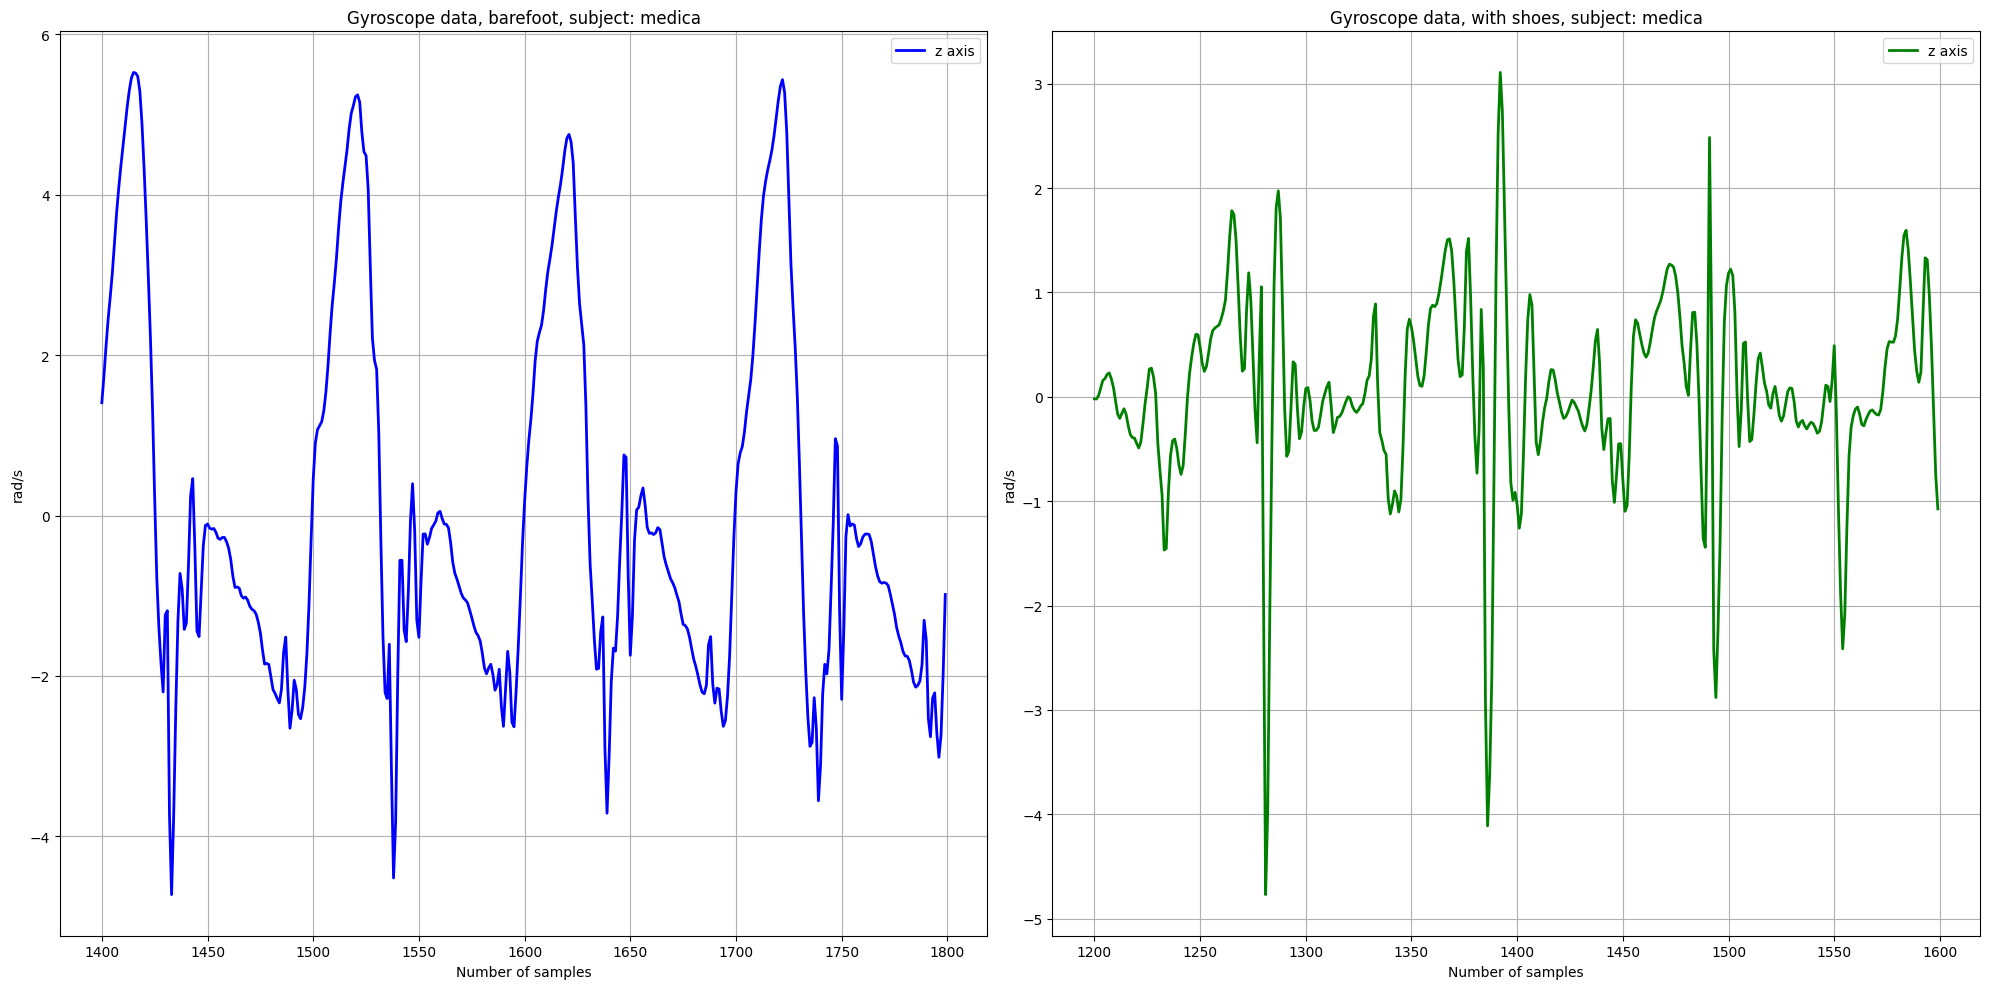

In [29]:
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.plot(Giroscopio[0][6]["z"][200:600], 'b', label="z axis",linewidth=2)
plt.title("Gyroscope data, barefoot, subject: " + nomi[6])
plt.xlabel("Number of samples")
plt.ylabel("rad/s")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Giroscopio[1][6]["z"][200:600], 'g', label="z axis",linewidth=2)
plt.title("Gyroscope data, with shoes, subject: " + nomi[6])
plt.xlabel("Number of samples")
plt.ylabel("rad/s")
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

In this visualization, the axis examined is "z". However, this time the data come from the gyroscope, an instrument that measures rotations. At the time of measurement, a positive rotation indicates an outward rotation, while a negative value indicates an inward rotation.

#### What do we notice?
1. The first thing that stands out is the size of the peaks. In fact, in the barefoot measurements the rotation is less violent.
2. The second observation concerns the recorded values. With the shoes, the outward rotation is limited.

## Filtering phase
In this section, __filters__ will be applied to the different __signals__.     
The __goal__ of filtering is to __reduce noise__ and improve data quality, making the __trend__ smoother and easier to interpret.         
Choosing a good filter is essential, since it will affect the subsequent analysis of the data.      
__Gaussian__ and __Savitzky–Golay__ filters will be used for the gyroscope and the accelerometer, respectively.


In [30]:
sigme = 1.1, 1.1, 1.2, 1.2, 1.4, 1.3, 1.1 ,1.1, 1, 1.2, 1.1, 1, 1.1, 1.1, 1, 1.2, 1.3, 1.1, 1.1, 1.3, 1.1, 1.2, 1.5, 1.4, 1.2, 1.3, 1, 1.2, 1.4, 1.4, 1.2, 1.3, 1, 1.2, 1.5, 1.4, 1.3, 1.4, 1.2, 1.3, 1.6, 1.4, 1.1, 1.4, 1, 1.2, 1.5, 1.1, 1.1, 1.2, 1.2, 1.1, 1.3, 1.1, 1.1, 1.1, 1, 1.1, 1.3, 1.1
assi = "x", "y", "z"

In [31]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.signal import savgol_filter


j=0
for i in range(size2):
    for asse in assi:
        Accelerometro[0][i][asse] = savgol_filter(Accelerometro[0][i][asse], window_length=11, polyorder=3)
        #print("applying sigma: ", sigme[j], " for axis: ", asse, " for subject: ", nomi[i], "barefoot")
        #Accelerometro[0][i][asse] = gaussian_filter(Accelerometro[0][i][asse], sigma=sigme[j])
        j += 1
    for asse in assi:
        Accelerometro[1][i][asse] = savgol_filter(Accelerometro[1][i][asse], window_length=11, polyorder=3)
        #print("applying sigma: ", sigme[j], " for axis: ", asse, " for subject: ", nomi[i], "with shoes")
        #Accelerometro[1][i][asse] = gaussian_filter(Accelerometro[1][i][asse], sigma=sigme[j])
        j += 1
    
j=0
for i in range(size2):
    for asse in assi:
        #print("applying sigma: ", sigme[j], " for axis: ", asse, " for subject: ", nomi[i], "barefoot")
        Giroscopio[0][i][asse] = gaussian_filter(Giroscopio[0][i][asse], sigma=sigme[j])
        j += 1
    for asse in assi:
        #print("applying sigma: ", sigme[j], " for axis: ", asse, " for subject: ", nomi[i], "with shoes")
        Giroscopio[1][i][asse] = gaussian_filter(Giroscopio[1][i][asse], sigma=sigme[j])
        j += 1


## Extracting features from the signals

In this section, some __features__ of the different signals will be __highlighted__.     
Naturally, once these features have been extracted, they will be visualized appropriately. The __goal__ will be to: observe __clustering__ among __subjects__ and, subsequently, __highlight__ the __differences__ between the signals collected __barefoot__ and __with football boots__.

### Function used to extract the features
The function defined below extracts: __Standard deviation__, __Total energy__ (sum of the squares of each value), __Dominant frequency__, __Maximum value__, __Mean value__ and __Range__ (val_max - val_min).

In [32]:
import numpy as np

def estrai_caratteristiche(seg):
    # Standard deviation
    std = np.std(seg)
    # Total energy
    energia = np.sum(seg**2)
# Dominant frequency
    seg2 = seg - np.mean(seg)
    N = len(seg2) # number of samples
    freqs = np.fft.rfftfreq(N, d=1/100) # positive frequency axis
    fft_vals = np.fft.rfft(seg2) # FFT of the signal
    potenza = np.abs(fft_vals)**2 # power spectrum
    # index of the maximum peak
    idx_max = np.argmax(potenza)
    freq_dominante = freqs[idx_max] # dominant frequency
#
    # Maximum value
    max_val = np.max(seg)
    # Mean
    val_medio = np.mean(seg)
    # Signal range (peak-to-peak)
    escursione = np.ptp(seg)
    
    return std, freq_dominante, max_val, val_medio, escursione

### Extraction phase
Below, relevant features are extracted from the signals.

In [33]:

# Example: extract for all subjects, 'x' axis
caratteristiche_acc = []
caratteristiche_gyr = []

for i in range(size2):
    # Accelerometer, barefoot
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Accelerometro[0][i]['x'])
    caratteristiche_acc.append([std, freq_dom, max_val, val_medio, escursione])
    # Gyroscope, barefoot
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Giroscopio[0][i]['z'])
    caratteristiche_gyr.append([std, freq_dom, max_val, val_medio, escursione])


for i in range(size2):
    # Accelerometer, with shoes
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Accelerometro[1][i]['x'])
    caratteristiche_acc.append([std, freq_dom, max_val, val_medio, escursione])
    # Gyroscope, with shoes
    std, freq_dom, max_val, val_medio, escursione = estrai_caratteristiche(Giroscopio[1][i]['z'])
    caratteristiche_gyr.append([std, freq_dom, max_val, val_medio, escursione])

# Now the features can be plotted with a scatter plot
caratteristiche_acc = np.array(caratteristiche_acc)
caratteristiche_gyr = np.array(caratteristiche_gyr)

### First plot
Here the focus will be on the clustering of subjects.

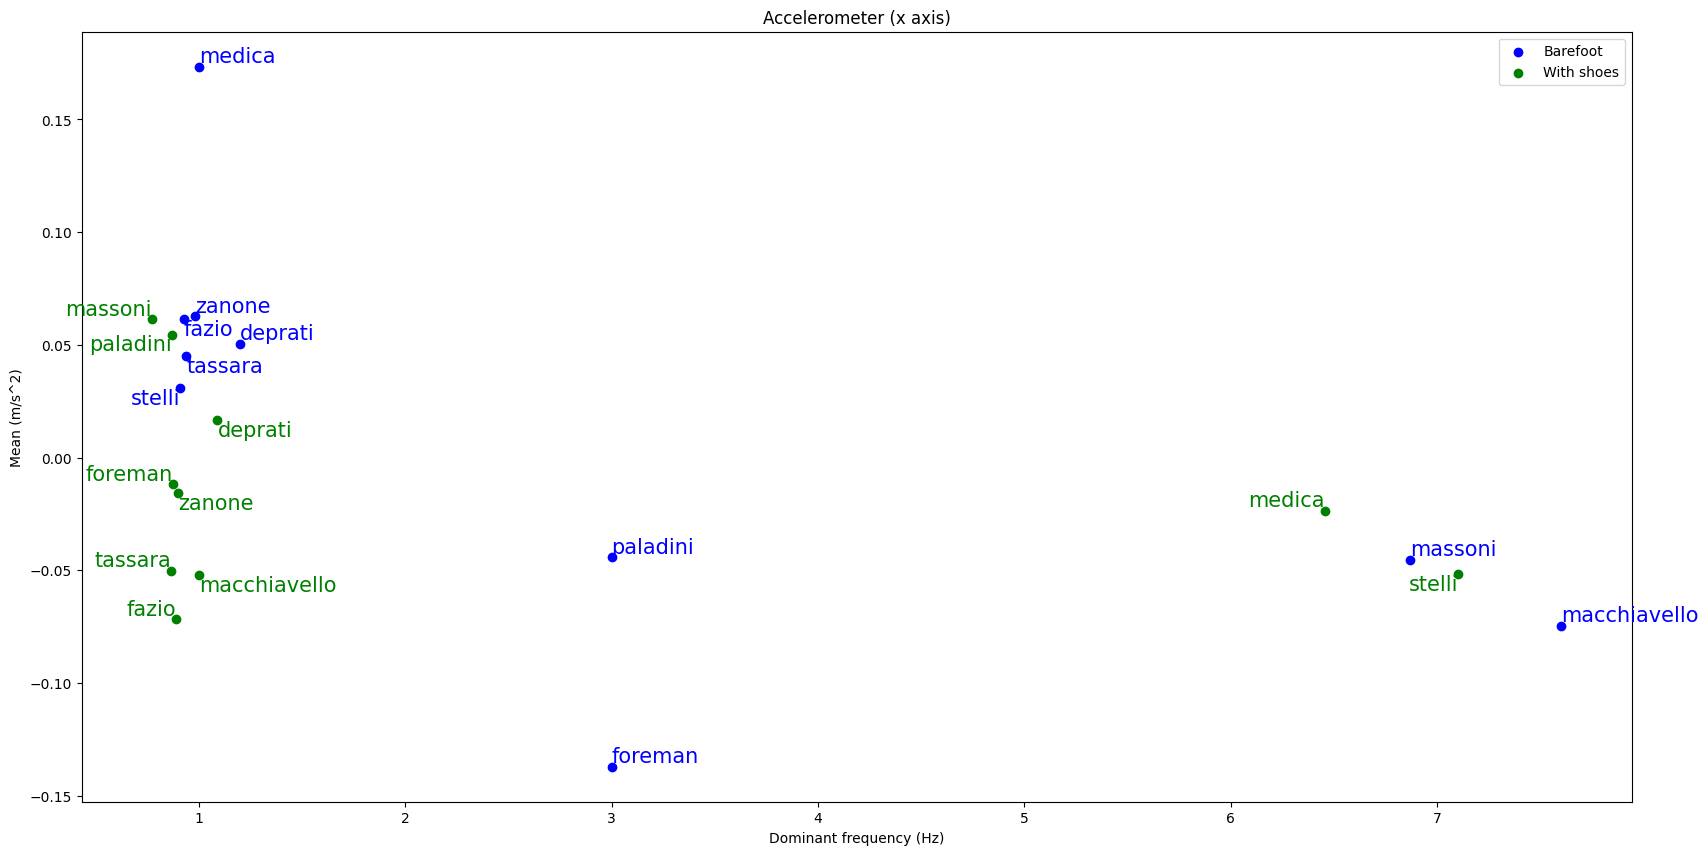

In [34]:
asse_x = 1 # Dominant frequency
asse_y = 3 # Mean

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_acc[:size2,asse_x], caratteristiche_acc[:size2,asse_y], color='blue')
plt.scatter(caratteristiche_acc[size2:,asse_x], caratteristiche_acc[size2:,asse_y], color='green')

# Add the names next to the points
for i, nome in enumerate(nomi):
    if nome == "stelli":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='right', va='top', color='blue')
    elif nome == "tassara":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    elif nome == "fazio":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "macchiavello":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "zanone":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "stelli":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    elif nome == "deprati":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "paladini":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Dominant frequency (Hz)')
plt.ylabel('Mean (m/s^2)')
plt.title('Accelerometer (x axis)')
plt.legend(['Barefoot', 'With shoes'])
plt.show()

#### Observations
1. Most signals have a dominant frequency of 1 Hz. This frequency is associated with normal human walking.
2. __paladini__ and __foreman__, barefoot, have a frequency of 3 Hz, which is usually associated with very fast walking or jogging.
3. __medica__ goes from a normal dominant frequency, 1 Hz, to an abnormal one, 6.5 Hz. A likely explanation is that, in the signal acquired with shoes, the dominant frequency is caused by the impact of the studs on the ground.
4. __deprati__, __tassara__, __fazio__ and __zanone__ show a change in the signal mean, which in fact becomes negative.
5. __deprati__ has a smaller variation in values than all the other signals.
6. For 8 subjects, football boots seem to normalize the gait.

### Second plot
Now the focus will be on the difference between the signals collected with the shoes and those collected without.

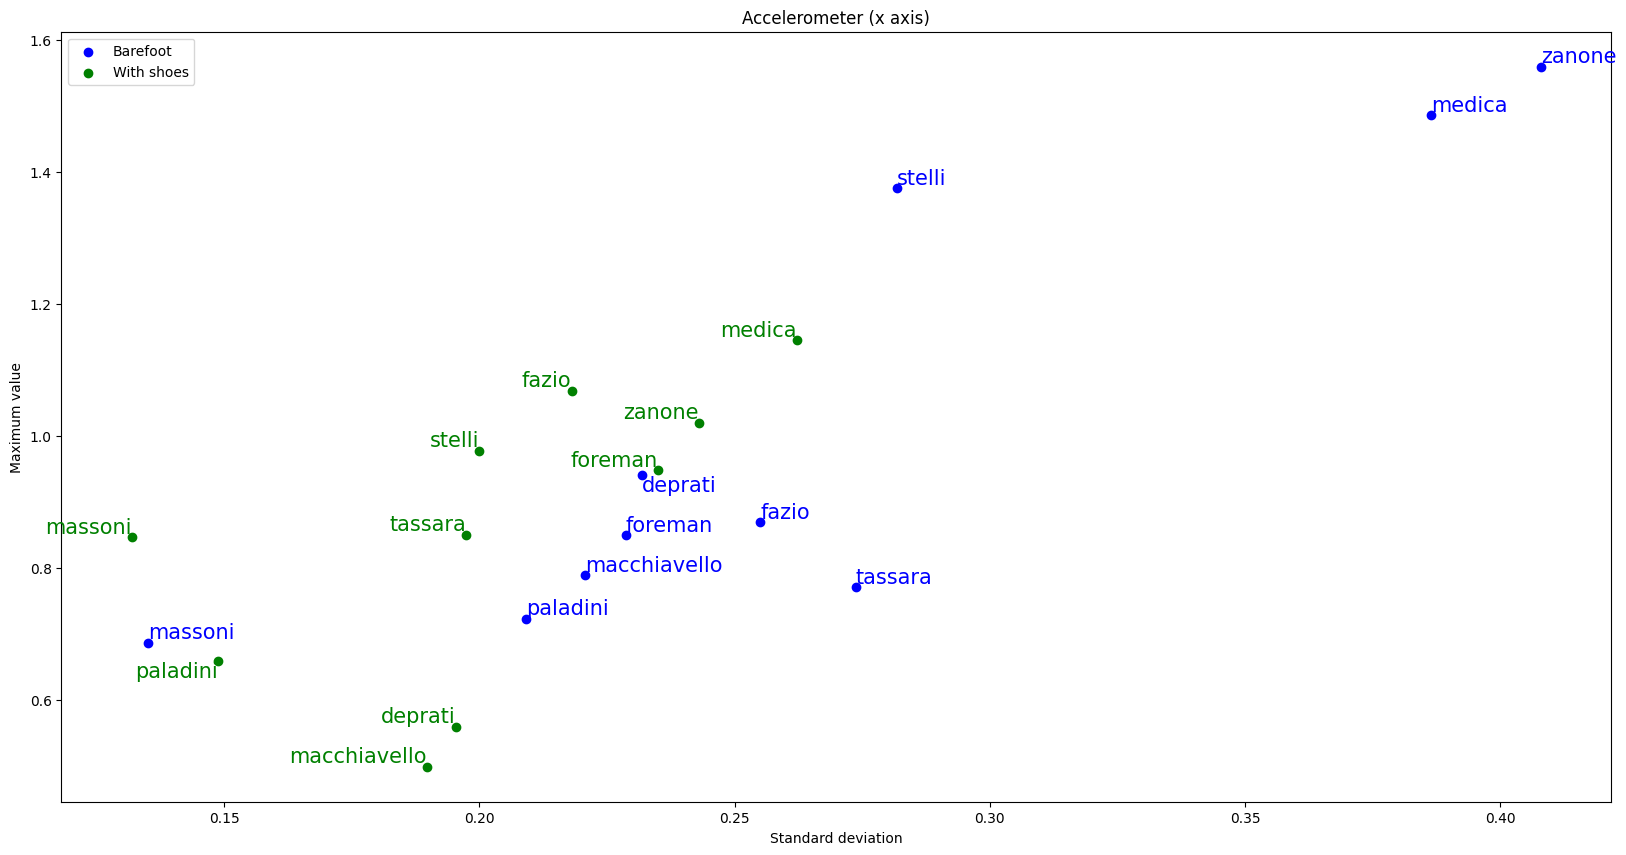

In [35]:
asse_x = 0 # Standard deviation
asse_y = 2 # Maximum value

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_acc[:size2,asse_x], caratteristiche_acc[:size2,asse_y], color='blue')
plt.scatter(caratteristiche_acc[size2:,asse_x], caratteristiche_acc[size2:,asse_y], color='green')

# Add the names next to the points
for i, nome in enumerate(nomi):
    if nome == "deprati":
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_acc[i,asse_x], caratteristiche_acc[i,asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "paladini":
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_acc[i+size2,asse_x], caratteristiche_acc[i+size2,asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Standard deviation')
plt.ylabel('Maximum value')
plt.title('Accelerometer (x axis)')
plt.legend(['Barefoot', 'With shoes'])
plt.show()

### Observations
1. There seems to be a sort of separation between the signals collected with football boots and those collected barefoot. __massoni__ is an outlier: his barefoot gait is very similar to the one with football boots.
2. Except for __foreman__ and __massoni__, the standard deviation decreases when football boots are used. Naturally, a football boot limits the movement the foot can make compared with going barefoot.

### Third plot
This visualization uses the gyroscope data.

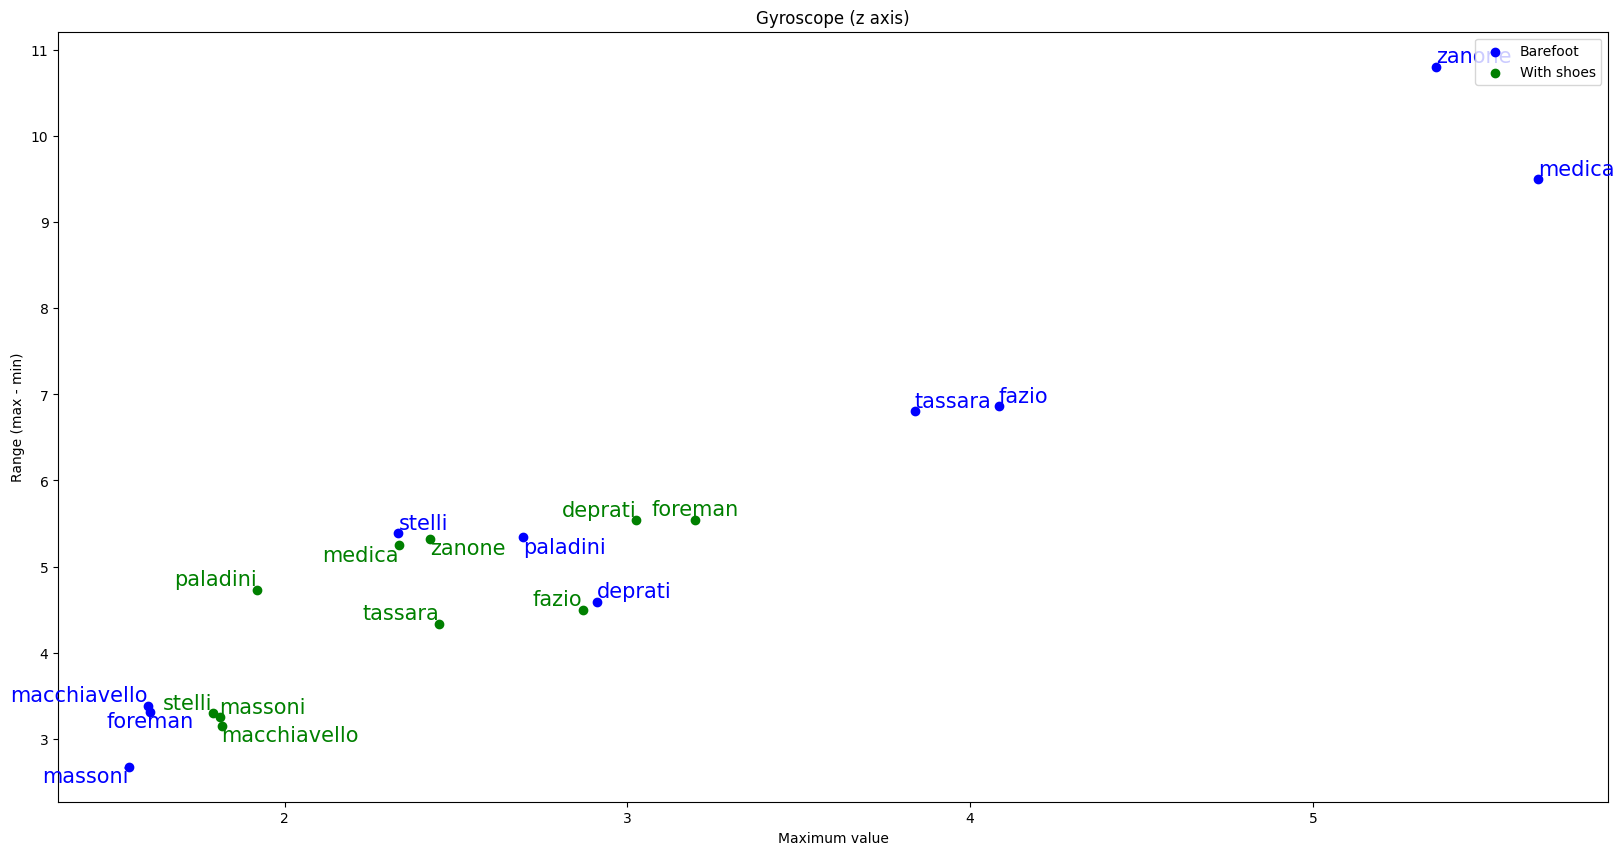

In [36]:
# std, freq_dominante, max_val, val_medio, escursione
asse_x = 2 # max_val
asse_y = 4 # range

plt.figure(figsize=(20,10))
plt.scatter(caratteristiche_gyr[:size2, asse_x], caratteristiche_gyr[:size2, asse_y], color='blue')
plt.scatter(caratteristiche_gyr[size2:, asse_x], caratteristiche_gyr[size2:, asse_y], color='green')

# Add the names next to the points
for i, nome in enumerate(nomi):
    if nome == "foreman":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='center', va='top', color='blue')
    elif nome == "massoni":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='right', va='top', color='blue')
    elif nome == "macchiavello":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='right', va='bottom', color='blue')
    elif nome == "paladini":
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='left', va='top', color='blue')
    else:
        plt.text(caratteristiche_gyr[i, asse_x], caratteristiche_gyr[i, asse_y], nome, fontsize=15, ha='left', va='bottom', color='blue')

for i, nome in enumerate(nomi):
    if nome == "macchiavello":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "massoni":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='bottom', color='green')
    elif nome == "foreman":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='center', va='bottom', color='green')
    elif nome == "zanone":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='left', va='top', color='green')
    elif nome == "medica":
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='right', va='top', color='green')
    else:
        plt.text(caratteristiche_gyr[i+size2, asse_x], caratteristiche_gyr[i+size2, asse_y], nome, fontsize=15, ha='right', va='bottom', color='green')

plt.xlabel('Maximum value')
plt.ylabel('Range (max - min)')
plt.title('Gyroscope (z axis)')
plt.legend(['Barefoot', 'With shoes'])
plt.show()

#### Observations
1. It is immediately clear that the range, when barefoot, can show considerable peaks. Indeed, both __tassara__ and __fazio__, who had always been close to the average, show slightly anomalous values.
2. In this case too, football boots seem to limit the values. This apparent limitation applies to both features, which in some respects means that the shoes normalize the gait.
3. __medica__ and __zanone__, when wearing football boots, produce values close to the average.

## Conclusion
In summary, the analysis confirmed that wearing football boots changes the gait, making it stiffer, with consequent changes in the signals collected by the accelerometer and the gyroscope. In particular, a greater constraint on movement was observed when football boots are worn.      
This confirms that football boots alter the biomechanics of the step.    
However, the study is limited to a small number of subjects and to normal experimental conditions. Moreover, only how the gait changes during light walking on a rigid, flat surface was examined.      
In any case, the study seems to confirm the hypothesis: "wearing football boots makes the gait stiffer, with a less natural, more rigid and robotic pattern".        
This manifests itself through:       
1. Accelerometer: more pronounced peaks are observed along the vertical axis (y), along with changes in the mean of the signal. In some cases, the mean even changes sign, which may indicate a change in weight distribution.
The dominant frequency across all signals remains about 1 Hz (a normal human step); however, for some subjects the dominant frequencies are higher than 6 Hz.        
2. Gyroscope: greater variety in the measurements is observed when the subject is not wearing shoes. In addition, the signal peaks are decidedly less steep. Conversely, when shoes are used, besides having steeper peaks, the walking pattern is more recognizable.        

An unexpected observation is the tendency toward normalization when shoes are used. Indeed, even though they make the gait more robotic and rigid, they reduce the variability of the signal features.        


In conclusion, the results seem to confirm that the presence of studs and the rigid structure of the boots influence the biomechanics of walking. It is true that they normalize the gait, but they alter the naturalness of the step, making it stiffer and forcing the foot into certain movements.
This makes it more unnatural.

## Acknowledgments
Special thanks go to the sports club ASD Vecchio Castagna Quarto. 
Above all, I would like to give special thanks to the lads: Stelli Lorenzo, Deprati Gabriele, Fazio Gabriele, Foreman Riccardo, Macchiavello Paride, Massoni Umberto, Medica Christian, Paladini Alessandro, Tassara Marco and Zanone Alessandro, who made the study possible by taking part with enthusiasm.